In [6]:
# Phase 3: Model Building & Evaluation

# Load the feature-engineered data, split into training and testing sets, train baseline models, and evaluate their performance.

In [7]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler # Optional, depending on model
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_recall_curve, auc,
    precision_score, recall_score
)
# Potentially import XGBoost or LightGBM if available and desired later
# import xgboost as xgb
# import lightgbm as lgb

# Adjust display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set a random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


print("Libraries imported.")

Libraries imported.


In [8]:
# Define path for feature-engineered data
data_dir = '../data'
input_file = os.path.join(data_dir, 'flights_features_v1.csv')

if not os.path.exists(input_file):
    raise FileNotFoundError(f"Feature-engineered data file not found at {input_file}. Make sure 03_feature_engineering.ipynb ran successfully.")

print(f"Loading feature-engineered data from: {input_file}")

df_model = pd.read_csv(input_file)

print("Feature-engineered dataset loaded successfully.")
print(f"Shape: {df_model.shape}")
print("Data types:")
df_model.info()

display(df_model.head())

Loading feature-engineered data from: ../data\flights_features_v1.csv
Feature-engineered dataset loaded successfully.
Shape: (2913802, 36)
Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2913802 entries, 0 to 2913801
Data columns (total 36 columns):
 #   Column                                      Dtype  
---  ------                                      -----  
 0   DISTANCE                                    float64
 1   CRS_ELAPSED_TIME                            float64
 2   IS_DELAYED                                  int64  
 3   YEAR                                        int64  
 4   MONTH                                       int64  
 5   DAY                                         int64  
 6   DAY_OF_WEEK                                 int64  
 7   DAY_OF_YEAR                                 int64  
 8   WEEK_OF_YEAR                                int64  
 9   DEP_HOUR                                    int64  
 10  DEP_MINUTE                                  int

,DISTANCE,CRS_ELAPSED_TIME,IS_DELAYED,YEAR,MONTH,DAY,DAY_OF_WEEK,DAY_OF_YEAR,WEEK_OF_YEAR,DEP_HOUR,DEP_MINUTE,ORIGIN_FREQ,DEST_FREQ,AIRLINE_Alaska Airlines Inc.,AIRLINE_Allegiant Air,AIRLINE_American Airlines Inc.,AIRLINE_Delta Air Lines Inc.,AIRLINE_Endeavor Air Inc.,AIRLINE_Envoy Air,AIRLINE_ExpressJet Airlines LLC d/b/a aha!,AIRLINE_Frontier Airlines Inc.,AIRLINE_Hawaiian Airlines Inc.,AIRLINE_Horizon Air,AIRLINE_JetBlue Airways,AIRLINE_Mesa Airlines Inc.,AIRLINE_PSA Airlines Inc.,AIRLINE_Republic Airline,AIRLINE_SkyWest Airlines Inc.,AIRLINE_Southwest Airlines Co.,AIRLINE_Spirit Air Lines,AIRLINE_United Air Lines Inc.,DEP_TIME_CATEGORY_Night,DEP_TIME_CATEGORY_Morning,DEP_TIME_CATEGORY_Afternoon,DEP_TIME_CATEGORY_Evening,DEP_TIME_CATEGORY_Late_Night
0,1065.0,186.0,0,2019,1,9,2,9,2,11,55,0.013416,0.017352,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0
1,1399.0,235.0,0,2022,11,19,5,323,46,21,20,0.020209,0.023853,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,680.0,118.0,0,2022,7,22,4,203,29,9,54,0.039934,0.020101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0
3,1589.0,260.0,1,2023,3,6,0,65,10,16,9,0.020209,0.019759,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
4,985.0,181.0,0,2020,2,23,6,54,8,18,40,0.021287,0.042915,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0


In [9]:
print("Separating features (X) and target (y)...")

# Define target variable name
target_col = 'IS_DELAYED'

if target_col not in df_model.columns:
    raise KeyError(f"Target column '{target_col}' not found in the dataframe.")

X = df_model.drop(columns=[target_col])
y = df_model[target_col]

print(f"Features shape (X): {X.shape}")
print(f"Target shape (y): {y.shape}")
print("\nTarget distribution:")
print(y.value_counts(normalize=True))

# Display sample features
print("\nSample features (X head):")
display(X.head())

Separating features (X) and target (y)...
Features shape (X): (2913802, 35)
Target shape (y): (2913802,)

Target distribution:
IS_DELAYED
0    0.823156
1    0.176844
Name: proportion, dtype: float64

Sample features (X head):


,DISTANCE,CRS_ELAPSED_TIME,YEAR,MONTH,DAY,DAY_OF_WEEK,DAY_OF_YEAR,WEEK_OF_YEAR,DEP_HOUR,DEP_MINUTE,ORIGIN_FREQ,DEST_FREQ,AIRLINE_Alaska Airlines Inc.,AIRLINE_Allegiant Air,AIRLINE_American Airlines Inc.,AIRLINE_Delta Air Lines Inc.,AIRLINE_Endeavor Air Inc.,AIRLINE_Envoy Air,AIRLINE_ExpressJet Airlines LLC d/b/a aha!,AIRLINE_Frontier Airlines Inc.,AIRLINE_Hawaiian Airlines Inc.,AIRLINE_Horizon Air,AIRLINE_JetBlue Airways,AIRLINE_Mesa Airlines Inc.,AIRLINE_PSA Airlines Inc.,AIRLINE_Republic Airline,AIRLINE_SkyWest Airlines Inc.,AIRLINE_Southwest Airlines Co.,AIRLINE_Spirit Air Lines,AIRLINE_United Air Lines Inc.,DEP_TIME_CATEGORY_Night,DEP_TIME_CATEGORY_Morning,DEP_TIME_CATEGORY_Afternoon,DEP_TIME_CATEGORY_Evening,DEP_TIME_CATEGORY_Late_Night
0,1065.0,186.0,2019,1,9,2,9,2,11,55,0.013416,0.017352,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0
1,1399.0,235.0,2022,11,19,5,323,46,21,20,0.020209,0.023853,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,680.0,118.0,2022,7,22,4,203,29,9,54,0.039934,0.020101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0
3,1589.0,260.0,2023,3,6,0,65,10,16,9,0.020209,0.019759,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
4,985.0,181.0,2020,2,23,6,54,8,18,40,0.021287,0.042915,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0


In [10]:
print("Splitting data into training and testing sets...")

# Given that this is time series data, we might want to split chronologically
# Let's use year 2023 as test set, and rest (2019-2022) as training data
# This better simulates a real-world scenario where we train on past data and predict future flights

# Check if YEAR column exists directly in X
if 'YEAR' in X.columns:
    X_train = X[X['YEAR'] < 2023]
    y_train = y[X['YEAR'] < 2023]
    
    X_test = X[X['YEAR'] == 2023]
    y_test = y[X['YEAR'] == 2023]
    
    print(f"Train set (2019-2022): {X_train.shape[0]:,} samples")
    print(f"Test set (2023): {X_test.shape[0]:,} samples")
    
    # Verify split proportions
    print(f"Train set proportion: {X_train.shape[0] / X.shape[0]:.2%}")
    print(f"Test set proportion: {X_test.shape[0] / X.shape[0]:.2%}")
else:
    # Fall back to random split if YEAR column isn't directly available
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_SEED
    )
    print(f"Train set (random split): {X_train.shape[0]:,} samples")
    print(f"Test set (random split): {X_test.shape[0]:,} samples")

Splitting data into training and testing sets...
Train set (2019-2022): 2,459,389 samples
Test set (2023): 454,413 samples
Train set proportion: 84.40%
Test set proportion: 15.60%


In [11]:
print("Training baseline models...")

# Dictionary to store models and their predictions
models = {}
predictions = {}
probabilities = {}  # For ROC curves later

# 1. Logistic Regression - Simple, interpretable
print("\n1. Logistic Regression")
log_reg = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000, n_jobs=-1)
log_reg.fit(X_train, y_train)
models['Logistic Regression'] = log_reg

# Make predictions
y_pred_log_reg = log_reg.predict(X_test)
predictions['Logistic Regression'] = y_pred_log_reg
probabilities['Logistic Regression'] = log_reg.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_log_reg))


# 2. Random Forest - Handles non-linear relationships well
print("\n2. Random Forest")
# Use n_estimators=100 as a starting point, can tune in Phase 4
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
rf.fit(X_train, y_train)
models['Random Forest'] = rf

# Make predictions
y_pred_rf = rf.predict(X_test)
predictions['Random Forest'] = y_pred_rf
probabilities['Random Forest'] = rf.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nBaseline models trained successfully.")

Training baseline models...

1. Logistic Regression
Accuracy: 0.7771
Classification Report:


c:\Users\ryanx\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ryanx\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ryanx\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.78      1.00      0.87    353119
           1       0.00      0.00      0.00    101294

    accuracy                           0.78    454413
   macro avg       0.39      0.50      0.44    454413
weighted avg       0.60      0.78      0.68    454413


2. Random Forest
Accuracy: 0.7691
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.96      0.87    353119
           1       0.42      0.10      0.16    101294

    accuracy                           0.77    454413
   macro avg       0.60      0.53      0.51    454413
weighted avg       0.71      0.77      0.71    454413


Baseline models trained successfully.


Visualizing model performance...


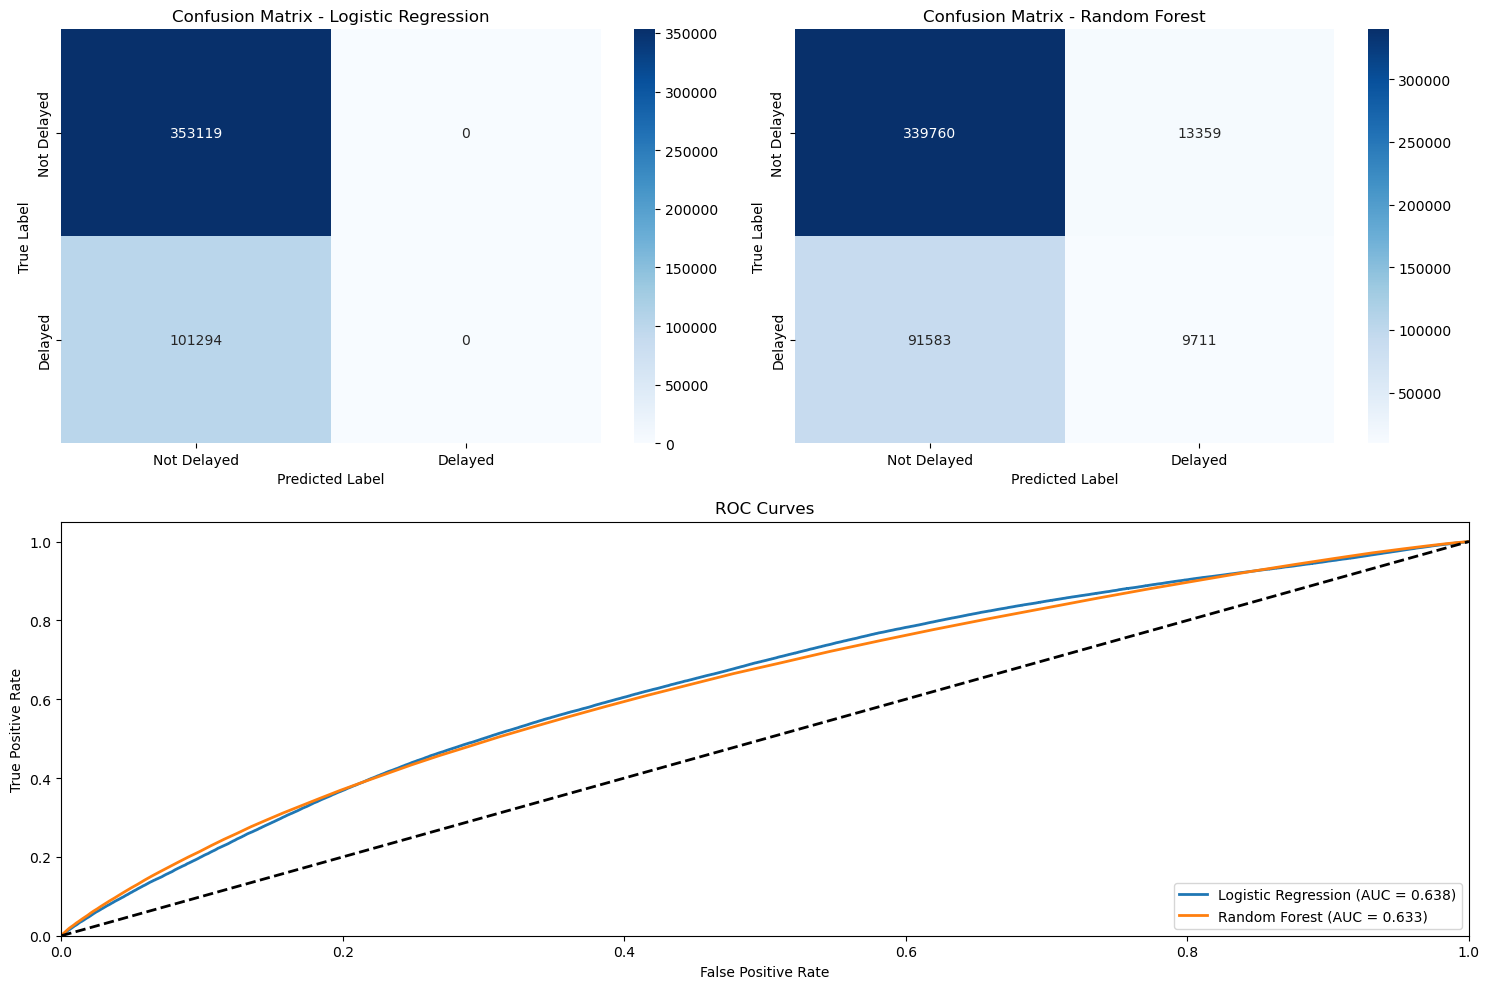


Class distribution in training data:
Not Delayed (0): 2,045,394 (83.17%)
Delayed (1): 413,995 (16.83%)


In [12]:
print("Visualizing model performance...")

# Set up plotting
plt.figure(figsize=(15, 10))

# 1. Confusion Matrices
plt.subplot(2, 2, 1)
cm_log_reg = confusion_matrix(y_test, predictions['Logistic Regression'])
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Delayed', 'Delayed'],
            yticklabels=['Not Delayed', 'Delayed'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.subplot(2, 2, 2)
cm_rf = confusion_matrix(y_test, predictions['Random Forest'])
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Delayed', 'Delayed'],
            yticklabels=['Not Delayed', 'Delayed'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# 2. ROC Curves
plt.subplot(2, 1, 2)
for model_name, model_probs in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, model_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

# 3. Class distribution in training data
print("\nClass distribution in training data:")
print(f"Not Delayed (0): {(y_train == 0).sum():,} ({(y_train == 0).mean():.2%})")
print(f"Delayed (1): {(y_train == 1).sum():,} ({(y_train == 1).mean():.2%})")

In [13]:
print("Training models with class balancing techniques...")

# 1. Logistic Regression with Class Weights
print("\n1. Logistic Regression with Class Weights")
log_reg_balanced = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000, 
                                     class_weight='balanced', n_jobs=-1)
log_reg_balanced.fit(X_train, y_train)
models['Logistic Regression (Balanced)'] = log_reg_balanced

# Make predictions
y_pred_log_reg_bal = log_reg_balanced.predict(X_test)
predictions['Logistic Regression (Balanced)'] = y_pred_log_reg_bal
probabilities['Logistic Regression (Balanced)'] = log_reg_balanced.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg_bal):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_log_reg_bal))


# 2. Random Forest with Class Weights
print("\n2. Random Forest with Class Weights")
rf_balanced = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, 
                                   class_weight='balanced', n_jobs=-1)
rf_balanced.fit(X_train, y_train)
models['Random Forest (Balanced)'] = rf_balanced

# Make predictions
y_pred_rf_bal = rf_balanced.predict(X_test)
predictions['Random Forest (Balanced)'] = y_pred_rf_bal
probabilities['Random Forest (Balanced)'] = rf_balanced.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_bal):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf_bal))

Training models with class balancing techniques...

1. Logistic Regression with Class Weights
Accuracy: 0.5862
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.57      0.68    353119
           1       0.30      0.63      0.41    101294

    accuracy                           0.59    454413
   macro avg       0.57      0.60      0.54    454413
weighted avg       0.72      0.59      0.62    454413


2. Random Forest with Class Weights
Accuracy: 0.7705
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.97      0.87    353119
           1       0.42      0.08      0.14    101294

    accuracy                           0.77    454413
   macro avg       0.60      0.52      0.50    454413
weighted avg       0.70      0.77      0.70    454413



In [14]:
# Cell 9: XGBoost with Class Weighting - FIXED
print("Approach #1: XGBoost with Class Weighting")
print("-----------------------------------------")

# Check if we have xgboost installed
try:
    import xgboost as xgb
    
    # Calculate class weights - FIXED: use np.array for classes
    from sklearn.utils.class_weight import compute_class_weight
    class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
    weight_dict = {0: class_weights[0], 1: class_weights[1]}
    
    # Prepare weights array - higher weight for minority class
    sample_weights = np.array([weight_dict[y] for y in y_train])
    
    # Train model with sample weights
    xgb_model = xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=RANDOM_SEED,
        n_jobs=-1
    )
    
    # Fit with sample weights
    xgb_model.fit(X_train, y_train, sample_weight=sample_weights)
    
    # Make predictions
    y_pred_xgb = xgb_model.predict(X_test)
    predictions['XGBoost (Weighted)'] = y_pred_xgb
    probabilities['XGBoost (Weighted)'] = xgb_model.predict_proba(X_test)[:, 1]
    
    print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred_xgb))
    
except ImportError:
    print("XGBoost not installed. Install with: pip install xgboost")

Approach #1: XGBoost with Class Weighting
-----------------------------------------
Accuracy: 0.5214
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.46      0.60    353119
           1       0.28      0.75      0.41    101294

    accuracy                           0.52    454413
   macro avg       0.57      0.60      0.50    454413
weighted avg       0.73      0.52      0.56    454413



In [15]:
# Cell 10: SMOTE Resampling
print("Approach #2: SMOTE Resampling")
print("-----------------------------")

try:
    from imblearn.over_sampling import SMOTE
    
    # Apply SMOTE to balance classes
    smote = SMOTE(random_state=RANDOM_SEED)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    
    print(f"Original class distribution - Not Delayed: {(y_train == 0).sum():,}, Delayed: {(y_train == 1).sum():,}")
    print(f"Resampled class distribution - Not Delayed: {(y_train_resampled == 0).sum():,}, Delayed: {(y_train_resampled == 1).sum():,}")
    
    # Train Random Forest on resampled data
    rf_smote = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
    rf_smote.fit(X_train_resampled, y_train_resampled)
    
    # Make predictions
    y_pred_rf_smote = rf_smote.predict(X_test)
    predictions['Random Forest (SMOTE)'] = y_pred_rf_smote
    probabilities['Random Forest (SMOTE)'] = rf_smote.predict_proba(X_test)[:, 1]
    
    print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_smote):.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred_rf_smote))
    
except ImportError:
    print("imbalanced-learn not installed. Install with: pip install imbalanced-learn")

Approach #2: SMOTE Resampling
-----------------------------
Original class distribution - Not Delayed: 2,045,394, Delayed: 413,995
Resampled class distribution - Not Delayed: 2,045,394, Delayed: 2,045,394
Accuracy: 0.7641
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.95      0.86    353119
           1       0.41      0.13      0.20    101294

    accuracy                           0.76    454413
   macro avg       0.60      0.54      0.53    454413
weighted avg       0.71      0.76      0.71    454413



In [16]:
# Cell 11: Threshold Optimization
print("Approach #3: Threshold Optimization")
print("---------------------------------")

from sklearn.metrics import f1_score

# For Random Forest model
rf_probs = probabilities['Random Forest']

# Try different thresholds
thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores = []

for threshold in thresholds:
    # Apply threshold
    y_pred_threshold = (rf_probs >= threshold).astype(int)
    # Calculate F1 score
    f1 = f1_score(y_test, y_pred_threshold)
    f1_scores.append(f1)
    
# Find best threshold
best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)
    
print(f"Best threshold: {best_threshold:.2f}, F1-Score: {best_f1:.4f}")

# Apply best threshold
y_pred_best_threshold = (rf_probs >= best_threshold).astype(int)
print("Classification Report with optimized threshold:")
print(classification_report(y_test, y_pred_best_threshold))

# Add to our predictions dictionary
predictions['Random Forest (Optimized Threshold)'] = y_pred_best_threshold

Approach #3: Threshold Optimization
---------------------------------
Best threshold: 0.20, F1-Score: 0.3984
Classification Report with optimized threshold:
              precision    recall  f1-score   support

           0       0.84      0.58      0.69    353119
           1       0.30      0.61      0.40    101294

    accuracy                           0.59    454413
   macro avg       0.57      0.60      0.54    454413
weighted avg       0.72      0.59      0.62    454413



Model Comparison
---------------


,Model,Accuracy,Precision,Recall,F1 Score
4,XGBoost (Weighted),0.521369,0.282865,0.747221,0.410379
2,Logistic Regression (Balanced),0.586161,0.298435,0.634075,0.405851
6,Random Forest (Optimized Threshold),0.589765,0.295945,0.609385,0.398406
5,Random Forest (SMOTE),0.764122,0.408719,0.130225,0.197517
1,Random Forest,0.769060,0.420936,0.095869,0.156171
3,Random Forest (Balanced),0.770513,0.422486,0.080390,0.135077
0,Logistic Regression,0.777088,0.000000,0.000000,0.000000


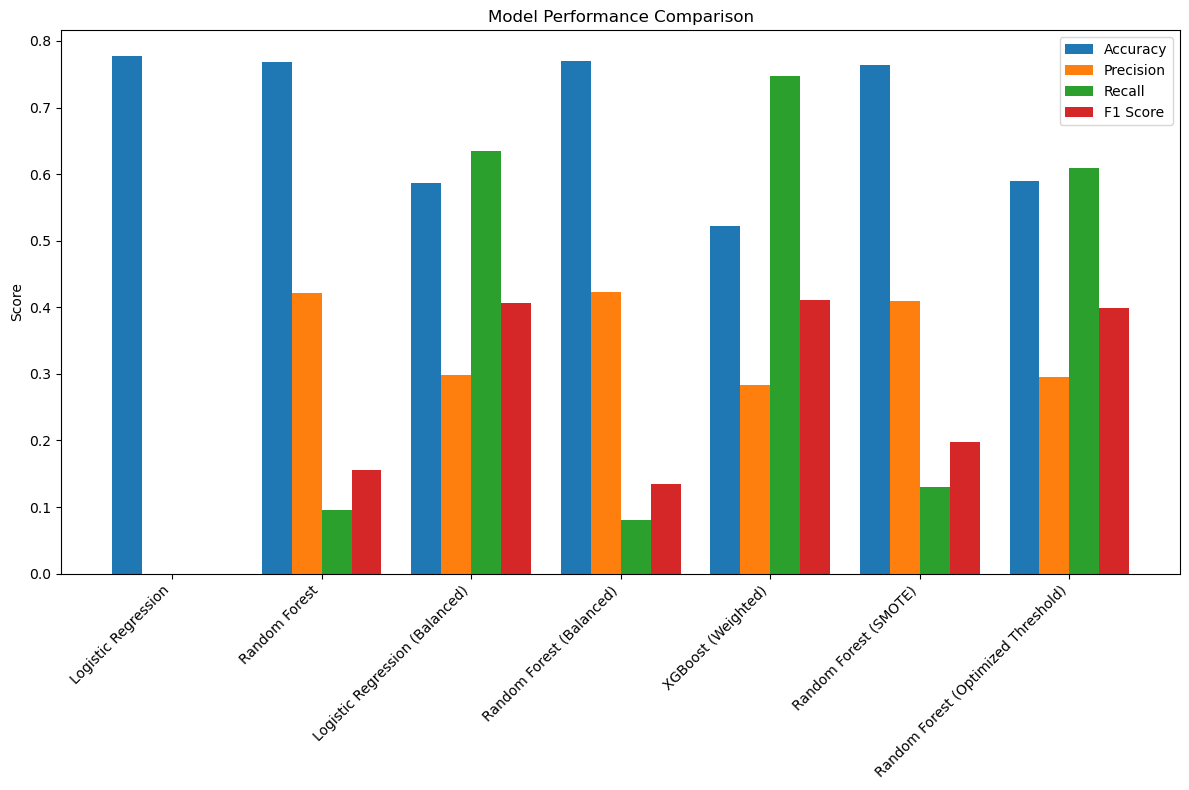

In [17]:
# Cell 12: Model Comparison
print("Model Comparison")
print("---------------")

# Collect results into a DataFrame
results = []

for model_name, y_pred in predictions.items():
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

results_df = pd.DataFrame(results)
display(results_df.sort_values('F1 Score', ascending=False))

# Visualize comparison
plt.figure(figsize=(12, 8))
models = results_df['Model']
x = np.arange(len(models))
width = 0.2

plt.bar(x - width*1.5, results_df['Accuracy'], width, label='Accuracy')
plt.bar(x - width/2, results_df['Precision'], width, label='Precision')
plt.bar(x + width/2, results_df['Recall'], width, label='Recall')
plt.bar(x + width*1.5, results_df['F1 Score'], width, label='F1 Score')

plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, models, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()